# TinyGPT

**Author: Abraham R.**

The following notebook is an example of a really tiny GPT based model called TinyGPT.
You'll review the GPT architecture (transformer decoder) and implement the following tasks:

## TinyGPT Architecture

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, this model consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek
- Mistral

## Tasks

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)

## Architecture:
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

## What to expect?

- You'll manage to understand a depth implementation of a GPT model.
- Implement a MoE Layer to create a state-of-the art GPT model.
- Explore decoding algorithms for text generation.


### NOTE

Tokenization is out of scope, we'll use a simple yet ineffective character-based tokenizer.


In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional, List, Type
import httpx
from transformers import AutoTokenizer

from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR

## Downloading Dataset

In [2]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

text = text[:100_000]  # Using 100k characters for speedup
print(text[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


# Character-based encoding

In [3]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
vocab_size = len(tokenizer)

def encode(s): return tokenizer.encode(s)
def decode(l): return tokenizer.decode(l)

data = torch.tensor(encode(text), dtype=torch.long)

# Train/test split
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


# Dataloaders

In [4]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# GPT Configuration

In [5]:
@dataclass
class MoEArgs():
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    num_experts_per_token : int = field(default=2)

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 8
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 8, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 50257, 'bias': True, 'ff_class': None, 'moe': None}


In [6]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers= 8,
                        )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [7]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

        # Combined QKV projection
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [8]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [9]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None

        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## TinyGPT Architecture

In [10]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits


## Generation function (inference)

In [11]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Setup

In [12]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
m = TinyGPT(config).to(device)
model = torch.compile(m)

In [13]:
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 2

# Training

In [14]:
# Trainer instance
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/3443 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
W0405 20:02:44.007000 8243 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/di

Epoch 1 training loss: 3.7443


  0%|          | 0/379 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
val_loss 7.46123: 100%|██████████| 379/379 [00:04<00:00, 88.61it/s] 


Epoch 1 validation loss: 4.9157


loss 3.77491: 100%|██████████| 3443/3443 [01:01<00:00, 56.10it/s]


Epoch 2 training loss: 3.7782


val_loss 7.48975: 100%|██████████| 379/379 [00:03<00:00, 102.94it/s]


Epoch 2 validation loss: 4.9248
Training complete.


### Quick test

In [15]:
generate("To be", max_new_tokens=100,use_cache=True)

"To be accused? iferers, as they So late, we wont\nSee what is the part in ' Wasrician\nYour suffering would set wisdom, you must my gulf mywon\nwereOur wrath no better bow not well welcome\n sets.\n\nCORIOLANUS:\nWhat it is the canon.\n This merry, tribunes, who words:\nThis true that, sir, my gods, little at\nHave, in high.\n\nSecond Citizen:\nD him"

# Task I

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)



In [16]:
@torch.no_grad()
def generateV2(
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 0.0,
) -> str:
    """
    Advanced text generation supporting multiple decoding strategies.

    Args:
        prompt: Input text to continue from.
        max_new_tokens: Number of tokens to generate.
        use_cache: Whether to use KV-cache for faster autoregressive generation.
        temperature: Controls randomness. 0 = greedy, <1 = sharper, >1 = more random.
        top_k: If >0, keep only the top-k highest probability tokens before sampling.
        top_p: If >0, use nucleus sampling: keep smallest set of tokens
               whose cumulative probability exceeds top_p.
    """
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None

        logits = logits[:, -1, :]  # (B, vocab_size)

        # Greedy decoding: pick the token with the highest logit (deterministic)
        if temperature == 0.0:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat((idx, next_token), dim=1)
            continue

        # Temperature scaling: divide logits to sharpen (T<1) or flatten (T>1) the distribution
        logits = logits / temperature

        # Top-k filtering: zero out everything except the k most probable tokens
        if top_k > 0:
            top_k_val = min(top_k, logits.size(-1))
            kth_vals = torch.topk(logits, top_k_val).values[:, -1:]
            logits = logits.masked_fill(logits < kth_vals, float('-inf'))

        # Top-p (nucleus) filtering: keep the smallest token set whose cumulative prob >= p
        if top_p > 0.0:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            # Shift right so the first token exceeding the threshold is still kept
            sorted_mask = (cumulative_probs - F.softmax(sorted_logits, dim=-1)) >= top_p
            sorted_logits[sorted_mask] = float('-inf')
            logits = sorted_logits.scatter(1, sorted_indices, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

## Compare generate vs generateV2

### Decoding strategies explained

| Strategy | Behaviour |
|---|---|
| **Original `generate`** | Samples from the full unmodified probability distribution (`torch.multinomial`). No temperature or filtering, so every token has a chance proportional to its softmax probability. |
| **Greedy (`temperature=0`)** | Always picks the single most probable token. Fully deterministic — identical prompts always produce identical outputs. Tends to be repetitive. |
| **Low temperature (0.5)** | Sharpens the distribution, making high-probability tokens even more likely. Less random than the original but not fully deterministic. |
| **High temperature (1.5)** | Flattens the distribution, giving lower-probability tokens a bigger chance. More creative/diverse but also noisier. |
| **Top-k** | Restricts sampling to the *k* most probable tokens, then re-normalizes. Prevents very unlikely tokens from being selected. |
| **Top-p (nucleus)** | Dynamically selects the smallest set of tokens whose cumulative probability exceeds *p*. Adapts the candidate set size to the shape of the distribution. |
| **Combined (top-k + top-p)** | Applies both filters: first top-k truncation, then top-p within the survivors. This is the strategy used by most production LLMs. |

In [17]:
prompt = "To be"

result_original = generate(prompt, max_new_tokens=100, use_cache=True)

result_greedy = generateV2(prompt, max_new_tokens=100, temperature=0.0)
result_temp_low = generateV2(prompt, max_new_tokens=100, temperature=0.5)
result_temp_high = generateV2(prompt, max_new_tokens=100, temperature=1.5)
result_topk = generateV2(prompt, max_new_tokens=100, temperature=0.8, top_k=10)
result_topp = generateV2(prompt, max_new_tokens=100, temperature=0.8, top_p=0.9)
result_combined = generateV2(prompt, max_new_tokens=100, temperature=0.8, top_k=20, top_p=0.9)

print("=== Original generate (multinomial from raw probs) ===")
print(result_original)
print("\n=== Greedy (temperature=0) ===")
print(result_greedy)
print("\n=== Low temperature (0.5) — more focused ===")
print(result_temp_low)
print("\n=== High temperature (1.5) — more random ===")
print(result_temp_high)
print("\n=== Top-k=10, temperature=0.8 ===")
print(result_topk)
print("\n=== Top-p=0.9 (nucleus), temperature=0.8 ===")
print(result_topp)
print("\n=== Combined: top-k=20 + top-p=0.9, temperature=0.8 ===")
print(result_combined)

=== Original generate (multinomial from raw probs) ===
To be.

SICINIUS:
Whether 'tis atus.

CORIUS:
He sway'll hear
Ssces are not lick innov.

Let of a otherwise the wholeIUS:
Here, orNothips from him.--

CORIOLANUS:
IThinkour, hang weep you,
Shall are not, Sic: therefore will so Custom
Int.
Now, the blood, though o' the friends

=== Greedy (temperature=0) ===
To be consul.

MENENIUS:
IOLANUS:
I'll hear,
I have been
And you have been the people,
And you have been the people,
And you have been the people,
And you have been the people,
And you have been the people,
And you have been the people,
And you have been the people,
And you have been the people,
And you have been the people,
And you

=== Low temperature (0.5) — more focused ===
To be consul.

CORIOLANUS:
He shall to see him,
And enough the people.

VIRGILIA:
They have seen you,
Than the people, I know,
And your own desert
And by the people, he did to your voices, and
He his chius,
And he shall be consul,
ShallIA: the thirdians,


## Task II
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

In [18]:
class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout)
        ) ## Example network

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x):
        return self.proj(x)

In [19]:
class MoELayer(nn.Module):
    """
    Mixture of experts FeedForward Layer
    """

    def __init__(self, experts : List[nn.Module], gate : nn.Module, moe_args : MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (B, T, n_embd)
        B, T, C = x.shape

        # Compute gating scores and select top-k experts per token
        gate_logits = self.gate(x)  # (B, T, num_experts)
        weights, selected_experts = torch.topk(gate_logits, self.args.num_experts_per_token)
        weights = F.softmax(weights, dim=-1)  # normalize across chosen experts

        # Prepare output tensor
        output = torch.zeros_like(x)

        # Flatten batch and sequence dims for easier indexing
        flat_x = x.view(-1, C)                              # (B*T, C)
        flat_selected = selected_experts.view(-1, self.args.num_experts_per_token)  # (B*T, k)
        flat_weights = weights.view(-1, self.args.num_experts_per_token)            # (B*T, k)
        flat_output = torch.zeros_like(flat_x)               # (B*T, C)

        for expert_idx, expert in enumerate(self.experts):
            # Boolean mask: which (token, slot) pairs route to this expert
            mask = (flat_selected == expert_idx)              # (B*T, k)
            token_mask = mask.any(dim=-1)                     # (B*T,)

            if not token_mask.any():
                continue

            # Run the expert only on its assigned tokens
            expert_input = flat_x[token_mask]                 # (n_tokens, C)
            expert_output = expert(expert_input)              # (n_tokens, C)

            # Weight by the gating coefficient (sum across slots that selected this expert)
            expert_weights = (flat_weights * mask.float()).sum(dim=-1, keepdim=True)  # (B*T, 1)
            flat_output[token_mask] += expert_output * expert_weights[token_mask]

        return flat_output.view(B, T, C)

In [20]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe.num_experts)],
            gate=Gate(config),
            moe_args=config.moe
        )

    def forward(self, x):
        return self.moe(x)

## Adding MoE to Config

In [21]:
config.ff_class = MoEFFN
config.moe = MoEArgs(num_experts=4, num_experts_per_token=1)

# Training TinyGPT-MoE


In [22]:
m_moe = TinyGPT(config).to(device)
model_moe = torch.compile(m_moe)

In [23]:
optimizer = AdamW(model_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 2

In [24]:
# Trainer instance
trainer = Trainer(
    model=model_moe,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/3443 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
loss 3.81179: 100%|██████████| 3443/3443 [02:30<00:00, 22.95it/s]


Epoch 1 training loss: 3.7285


  0%|          | 0/379 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
val_loss 7.35520: 100%|██████████| 379/379 [00:06<00:00, 61.58it/s]


Epoch 1 validation loss: 4.9338


loss 3.76031: 100%|██████████| 3443/3443 [02:28<00:00, 23.25it/s]


Epoch 2 training loss: 3.8204


val_loss 7.39043: 100%|██████████| 379/379 [00:06<00:00, 60.67it/s]

Epoch 2 validation loss: 4.9413
Training complete.


### Quick test — TinyGPT-MoE

In [25]:
# Temporarily swap the global model so generateV2 uses the MoE model
_prev_model = model
model = model_moe

print("=== MoE Greedy ===")
print(generateV2("To be", max_new_tokens=100, temperature=0.0))
print("\n=== MoE Top-k=10, temperature=0.8 ===")
print(generateV2("To be", max_new_tokens=100, temperature=0.8, top_k=10))
print("\n=== MoE Top-p=0.9, temperature=0.8 ===")
print(generateV2("To be", max_new_tokens=100, temperature=0.8, top_p=0.9))

model = _prev_model

=== MoE Greedy ===
To be
And the people,
And, and the people,
And, and the people,
And,
To the people,
And,
And,
And, sir, sir, sir, sir,
And you have been a man,
And you have been a man,
And you have been a man,
And you have been a man,
And you have been a man,
And you have been a man,
And you have been a man,

=== MoE Top-k=10, temperature=0.8 ===
To beENIUS:
I do.

First Citizen:
I have been enemy'stongENIUS:
The gods, to the people's a man,
To the Capitol.

First Officer:
He hasTis, my fellows, and,
He hath' the people, sir,
To the city we have been a brace, if
To be content.

COMINIUS:
That he is he is the city,
I

=== MoE Top-p=0.9, temperature=0.8 ===
To be they have.

CORIOLANUS:
Be that the people, to the whole people?

VOLUMNIA:
IOLANUS:
I am to the people,
A crack'd you are but the city not care your loves,
As qu, no more: I will
And behind.

BRUTUS:
He'llam, thou, when,
O, if he hathtis'd,
Were thou camINIUS


## Visualizing Attention

As we know, a GPT has the task to complete text, let's see the attention maps generated by a pretrained model

In [26]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Run forward with return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    # all_weights is a list of length n_layers
    # each element: shape (n_heads, batch_size, seq_len, seq_len)
    # We'll visualize the first batch element only

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()


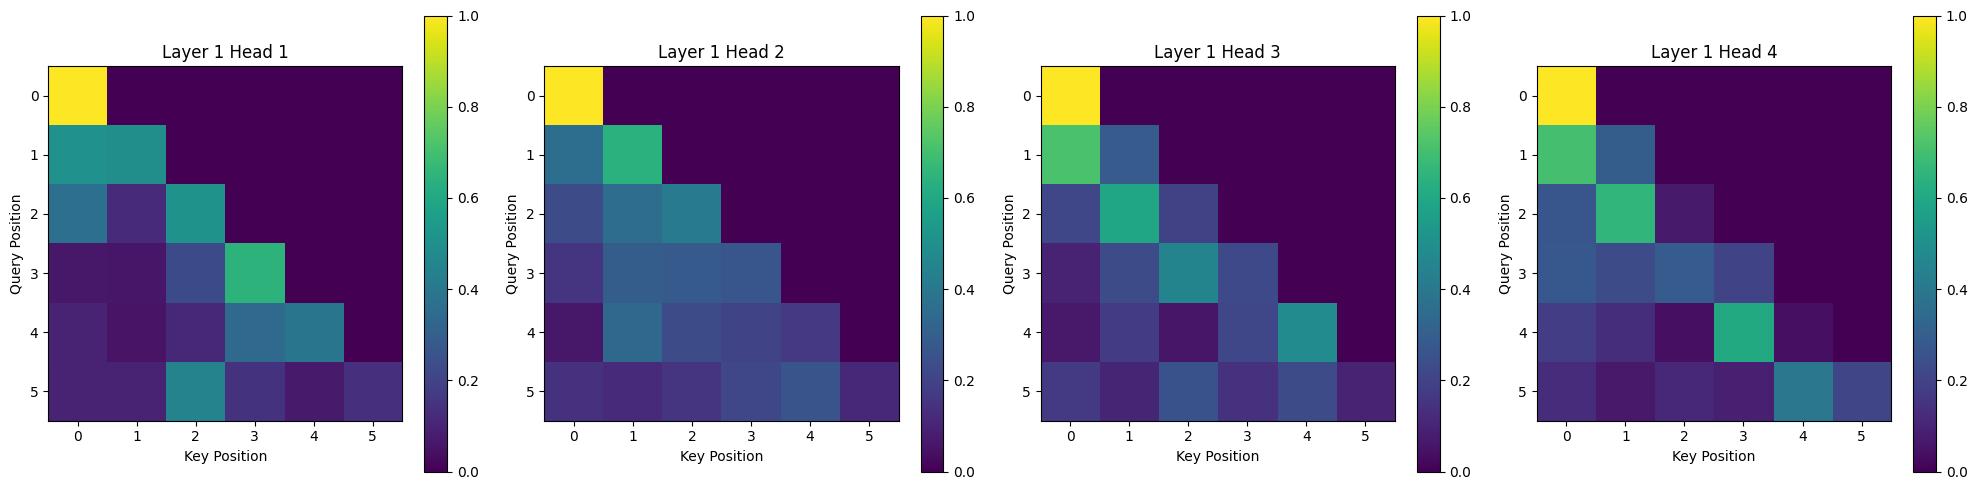

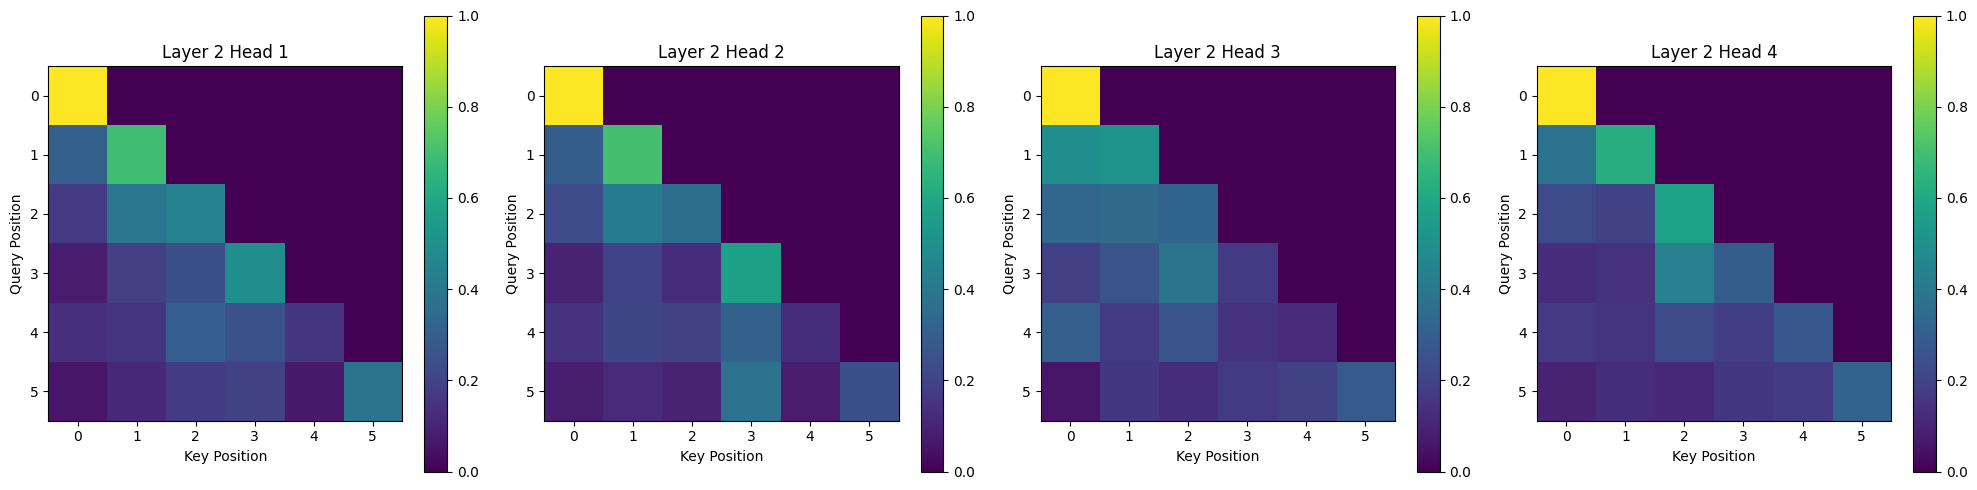

In [27]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

# Conclusions

- **Decoding strategies**: Greedy decoding is deterministic and fast but tends to produce repetitive text. Temperature sampling provides a smooth control knob between deterministic and creative outputs. Top-k and top-p (nucleus) sampling effectively truncate the tail of the distribution, preventing low-probability "garbage" tokens from being sampled while still preserving diversity. Combining top-k + top-p with a moderate temperature (e.g. 0.8) typically yields the best balance between coherence and variety.
- **Mixture of Experts (MoE)**: Replacing the dense FFN with a MoE layer increases the model's total parameter count without proportionally increasing compute per forward pass, since only a subset of experts is active for each token. The gating network learns to route tokens to specialized experts, allowing different parts of the network to focus on different patterns in the data. With the same training budget, MoE models can match or exceed the quality of dense models at lower inference cost.

# Congratulations! 🎉

After completing the tasks you've successfully pretrained for first GPT, remember to add your conclusions and findings! And you can now brag to your friend on how LLMs and GPTs work!

